In [ ]:
import torch
from torchvision import datasets, transforms
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.2860,), (0.3530,))])  # Tramsforming PIL image object into Pytorch tensor ( 1 channel ( grayscale)) followed by normalising data (relative deviation of pixel brightness from average instead of just pixel brighness)
FashionMNIST_train = datasets.FashionMNIST(root = 'data', train = True, download = True, transform = transform)
FashionMNIST_test = datasets.FashionMNIST(root = 'data', train = False, download = True, transform = transform)
FashionMNIST_train, FashionMNIST_val = random_split(FashionMNIST_train, [50000, 10000])   # splitting the 60000 images into 50000 and 10000 images randomly for training and validation
train_loader = DataLoader(FashionMNIST_train, batch_size = 64, shuffle = True)  # Loading in batches of 64 images ( Not heavy too on memory and also time efficient)
val_loader = DataLoader(FashionMNIST_val, batch_size = 64, shuffle = False)
test_loader = DataLoader(FashionMNIST_test, batch_size = 64, shuffle = False)


100%|██████████| 26.4M/26.4M [00:01<00:00, 17.9MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 306kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.64MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 19.5MB/s]


In [ ]:
class FashionNet(nn.Module):    # Inheriting properties from nn.Module class
  def __init__(self):
    super().__init__()            # To kickstarting the nn.Module class
    self.flatten = nn.Flatten()   # 28*28 into 784
    self.trunk = nn.Linear(784,16)  #First Hidden layer
    self.branch11 = nn.Linear(16,8) #1st step of Branch 1
    self.branch12 = nn.Linear(8,8)  #2nd step of Branch 1
    self.branch21 = nn.Linear(16,12)  #1st step of Branch 2
    self.branch22 = nn.Linear(12,8)   #2nd step of Branch 2
    self.output = nn.Linear(16,10)    # output layer
  def forward(self,x):
    x = self.flatten(x)
    a = torch.relu(self.trunk(x))     # Activation is added to introduce non-linearity
    # Branch 1
    b1 = torch.relu(self.branch11(a))
    b11 = torch.relu(self.branch12(b1))
    b_final1 = b11 + b1
    # Branch 2
    b2 = torch.relu(self.branch21(a))
    b_final2 = torch.relu(self.branch22(b2))
    #Combine the outputs
    combined = torch.concat((b_final1, b_final2), dim = 1)
    return self.output(combined)

In [ ]:
model = FashionNet()
print(model)

FashionNet(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (trunk): Linear(in_features=784, out_features=16, bias=True)
  (branch11): Linear(in_features=16, out_features=8, bias=True)
  (branch12): Linear(in_features=8, out_features=8, bias=True)
  (branch21): Linear(in_features=16, out_features=12, bias=True)
  (branch22): Linear(in_features=12, out_features=8, bias=True)
  (output): Linear(in_features=16, out_features=10, bias=True)
)


In [ ]:
from torch.optim import optimizer
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr =0.001)


In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
num_epoch = 5       #No. of cycle to train

# Training Phase
train_losses = []
val_losses = []
val_accs = []
train_accs = []
for epoch in range(num_epoch):
  model.train()       #Setting the model to train mode
  correct = 0
  total_loss = 0
  total = 0
  running_loss = 0.0
  for images, labels in train_loader:
    images, labels = images.to(device), labels.to(device)
    optimizer.zero_grad()           #Zeroing the gradients so that the gradients of previous batch are cleared
    outputs = model(images)
    loss = criterion(outputs, labels)
    loss.backward()
    optimizer.step()
    predicted = outputs.argmax(1)     #Returns the label with highest probability among the logits
    total += labels.size(0)
    correct += (predicted == labels).sum().item()
    running_loss += loss.item()
  total_loss = running_loss / len(train_loader)
  train_acc = correct / total
  train_accs.append(train_acc)
  print("Accuracy: ", train_acc)
  print(f'Epoch {epoch+1}/{num_epoch}, Loss: {total_loss:.4f}')
  train_losses.append(total_loss)
  model.eval()                    # Setting the model to test mode
  with torch.no_grad():           #Skipping gradient calculations
    correct = 0
    running_loss = 0.0
    total = 0
    for images, labels in val_loader:
      images, labels = images.to(device), labels.to(device)
      outputs = model(images)
      _, predicted = torch.max(outputs, 1)
      correct += (predicted == labels).sum().item()
      total += labels.size(0)
      loss = criterion(outputs, labels)
      running_loss += loss.item()
    val_loss = running_loss / len(val_loader)
    val_losses.append(val_loss)
    accuracy = correct / total
    val_accs.append(accuracy)
    print(f'Validation Loss: {val_loss:.4f}, Accuracy: {accuracy:.4f}')

Accuracy:  0.77264
Epoch 1/5, Loss: 0.6356
Validation Loss: 0.4606, Accuracy: 0.8347
Accuracy:  0.84656
Epoch 2/5, Loss: 0.4240
Validation Loss: 0.4210, Accuracy: 0.8468
Accuracy:  0.85896
Epoch 3/5, Loss: 0.3920
Validation Loss: 0.3947, Accuracy: 0.8581
Accuracy:  0.86624
Epoch 4/5, Loss: 0.3727
Validation Loss: 0.4059, Accuracy: 0.8539
Accuracy:  0.87094
Epoch 5/5, Loss: 0.3566
Validation Loss: 0.3757, Accuracy: 0.8616


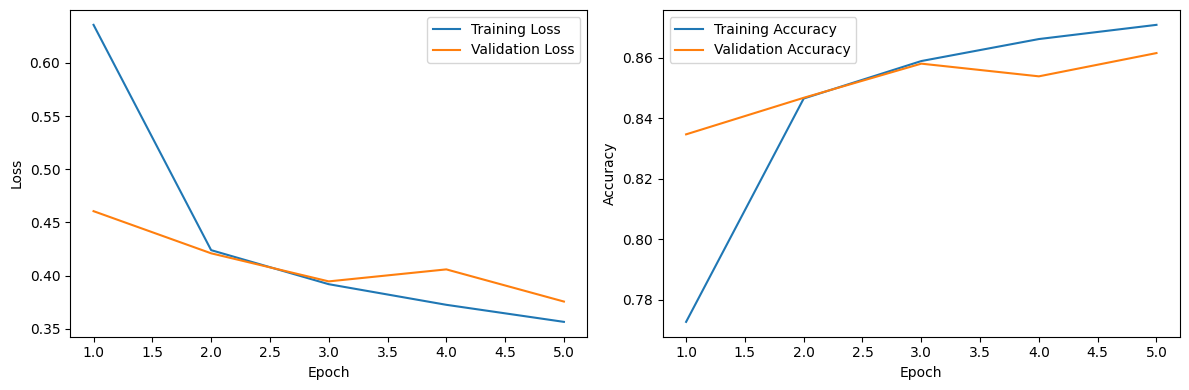

In [ ]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1,2, figsize = (12,4))
ax[0].plot(range(1,num_epoch+1), train_losses, label = 'Training Loss')
ax[0].plot(range(1,num_epoch+1), val_losses, label = 'Validation Loss')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel("Loss")
ax[1].plot(range(1,num_epoch+1), train_accs, label = 'Training Accuracy')
ax[1].plot(range(1,num_epoch+1), val_accs, label = 'Validation Accuracy')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel("Accuracy")
ax[0].legend()
ax[1].legend()
plt.tight_layout()
plt.savefig('plots.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
import pickle
with open('model_weights.pkl', 'wb') as f:
  pickle.dump(model.state_dict(), f)        #Writting the weights to the binary file
with open('model_weights.pkl', 'rb') as f:
  loaded_state = pickle.load(f)             #printing the weights from the binary file
print(loaded_state.keys())


odict_keys(['trunk.weight', 'trunk.bias', 'branch11.weight', 'branch11.bias', 'branch12.weight', 'branch12.bias', 'branch21.weight', 'branch21.bias', 'branch22.weight', 'branch22.bias', 'output.weight', 'output.bias'])


In [19]:
model.eval()
all_preds = []
with torch.no_grad():
  for images, labels in test_loader:
    images, labels = images.to(device), labels.to(device)
    outputs = model(images)
    predicted = torch.argmax(outputs,1)
    all_preds.append(predicted.cpu())
all_preds = torch.cat(all_preds).numpy()


In [20]:
import pandas as pd
df = pd.DataFrame({
    "ImageId": range(1,len(all_preds)+1),
    "label": all_preds
})
df.to_csv('submission.csv', index = False)

In [25]:
from google.colab import drive
drive.mount('/content/drive')

import shutil
shutil.copy('model_weights.pkl', '/content/drive/MyDrive/spider_ml/')
shutil.copy('submission.csv', '/content/drive/MyDrive/spider_ml/')
shutil.copy('plots.png', '/content/drive/MyDrive/spider_ml/')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


'/content/drive/MyDrive/spider_ml/plots.png'